# 🎥 Video 09: SMARTS Grammar & Substructure Searching
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 4 — SMARTS & Substructure Search (Topics 20, 21, 22, 24)
* **Target Audience:** Cheminformatics Engineers, Medicinal Chemists, Computational Biologists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 05:00** | SMILES vs SMARTS: Molecular Representation vs Chemical Pattern Matching
* **05:00 - 10:00** | SMARTS Syntax: Atomic Primitives, Bonds, and Logical Operators
* **10:00 - 14:30** | Substructure Matching: `mol.HasSubstructMatch()` vs `mol.GetSubstructMatches()`
* **14:30 - 19:30** | Detecting 10 Key Medicinal Functional Groups (Alcohols, Amines, Carboxylic acids, etc.)
* **19:30 - 24:30** | Highlighting Matched Substructures in 2D Structure Grids
* **24:30 - 27:30** | Pharmacophore Search in a Large Compound Library
* **27:30 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Understand the difference between SMILES (exact molecule) and SMARTS (query pattern with wildcard logic).
2. Master SMARTS grammar: atomic symbols (`c`, `[#6]`), valence (`v`), ring membership (`r`), and logical operators (`!`, `&`, `,`).
3. Query molecules programmatically with `HasSubstructMatch()` and extract atom indices with `GetSubstructMatches()`.
4. Build a comprehensive functional group detector for automated chemical classification.
5. Highlight matched pharmacophore motifs in 2D grid depictions.

In [1]:
# Step 0: Imports and Environment Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (320, 220)

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. SMILES vs SMARTS
* **SMILES:** Describes a complete, concrete molecule (e.g. `CCO` is ethanol).
* **SMARTS (SMiles ARbitrary Target Specification):** An extension of SMILES designed to express **queries, structural patterns, and substructures**.
  * `[#6]` = Any Carbon atom (aliphatic or aromatic).
  * `[#7]` = Any Nitrogen atom.
  * `[OH]` = An Oxygen with exactly one hydrogen (Alcohol or Acid).
  * `[!#6]` = Any heteroatom (NOT Carbon).
  * `[r5]` = An atom in a 5-membered ring.

In [2]:
# Load Paracetamol and create a SMARTS query for Phenol core
paracetamol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")
phenol_smarts = Chem.MolFromSmarts("c1ccc(O)cc1")

has_match = paracetamol.HasSubstructMatch(phenol_smarts)
print(f"Does Paracetamol contain a Phenol core? {has_match}")

matches = paracetamol.GetSubstructMatches(phenol_smarts)
print(f"Matched atom indices: {matches}")

Does Paracetamol contain a Phenol core? True
Matched atom indices: ((4, 5, 6, 7, 8, 9, 10),)


## 2. Detecting Key Medicinal Functional Groups
Let's build a functional group detector dictionary using SMARTS patterns.

In [3]:
functional_groups = {
    "Alcohol": "[OX2H]",
    "Primary Amine": "[NX3;H2;!$(NC=O)]",
    "Secondary Amine": "[NX3;H1;!$(NC=O)]",
    "Tertiary Amine": "[NX3;H0;!$(NC=O)]",
    "Carboxylic Acid": "[CX3](=O)[OX2H1]",
    "Ester": "[CX3](=O)[OX2H0][#6]",
    "Amide": "[NX3][CX3](=[OX1])[#6]",
    "Aromatic Ring": "a1aaaaa1",
    "Sulfonamide": "[#16X4](=[OX1])(=[OX1])([#7])",
    "Halogen": "[F,Cl,Br,I]"
}

# Compile SMARTS queries
compiled_patterns = {name: Chem.MolFromSmarts(smarts) for name, smarts in functional_groups.items()}

# Profile Ibuprofen, Aspirin, and Paracetamol
drugs = {
    "Aspirin": Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O"),
    "Ibuprofen": Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    "Paracetamol": Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")
}

profiling_results = []
for drug_name, mol in drugs.items():
    row = {"Drug": drug_name}
    for fg_name, pattern in compiled_patterns.items():
        row[fg_name] = len(mol.GetSubstructMatches(pattern))
    profiling_results.append(row)

df_fg = pd.DataFrame(profiling_results)
print("=== 📋 FUNCTIONAL GROUP DETECTION MATRIX ===")
display(df_fg)

=== 📋 FUNCTIONAL GROUP DETECTION MATRIX ===


,Drug,Alcohol,Primary Amine,Secondary Amine,Tertiary Amine,Carboxylic Acid,Ester,Amide,Aromatic Ring,Sulfonamide,Halogen
0,Aspirin,1,0,0,0,1,1,0,1,0,0
1,Ibuprofen,1,0,0,0,1,0,0,1,0,0
2,Paracetamol,1,0,0,0,0,0,1,1,0,0


## 3. Highlighting Substructure Matches in 2D Grids
When presenting hits to medicinal chemists, visually highlighting the matched core substructure is essential.

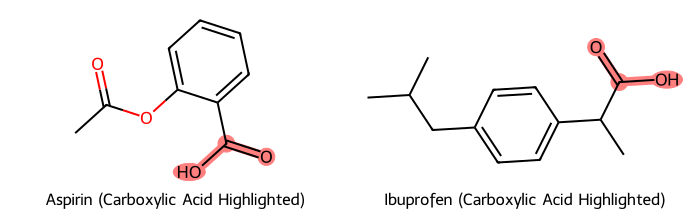

In [4]:
# Highlight the Carboxylic Acid group in Aspirin and Ibuprofen
acid_smarts = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")

mols_to_draw = [drugs["Aspirin"], drugs["Ibuprofen"]]
matched_atom_lists = [m.GetSubstructMatch(acid_smarts) for m in mols_to_draw]
legends = ["Aspirin (Carboxylic Acid Highlighted)", "Ibuprofen (Carboxylic Acid Highlighted)"]

Draw.MolsToGridImage(
    mols_to_draw,
    legends=legends,
    highlightAtomLists=matched_atom_lists,
    molsPerRow=2,
    subImgSize=(350, 220)
)

## 4. Screening a Chemical Library for a Pharmacophore Core
Let's search our EGFR dataset for compounds containing the **4-anilinoquinazoline kinase hinge-binder core**.

Found 155 compounds containing the 4-anilinoquinazoline core!


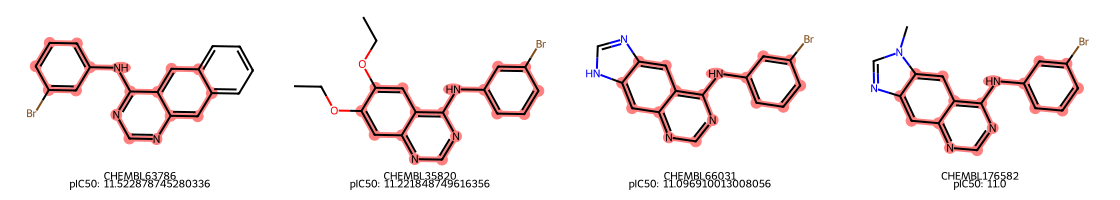

In [5]:
# 4-anilinoquinazoline core SMARTS
# Pyrimidine ring with two nitrogens, fused to benzene, substituted with an aromatic amine (NH-c)
quinazoline_core_smarts = Chem.MolFromSmarts("c1ccc2ncnc(Nc3ccccc3)c2c1")

candidate_paths = [
    "datasets/EGFR_compounds.csv",
    "../datasets/EGFR_compounds.csv",
    "../../datasets/EGFR_compounds.csv",
    os.path.expanduser("~/Projects/AI-Engineer-for-Life-Sciences-Libraries/Cheminformatics/RDKit/datasets/EGFR_compounds.csv")
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path:
    df_egfr = pd.read_csv(csv_path).head(300)
    matching_compounds = []
    
    for _, row in df_egfr.iterrows():
        m = Chem.MolFromSmiles(row["smiles"])
        if m and m.HasSubstructMatch(quinazoline_core_smarts):
            matching_compounds.append((row["molecule_chembl_id"], m, row.get("pIC50", "N/A")))
            
    print(f"Found {len(matching_compounds)} compounds containing the 4-anilinoquinazoline core!")
    
    # Draw first 4 matching hits with highlights
    if matching_compounds:
        sample_hits = matching_compounds[:4]
        hit_mols = [item[1] for item in sample_hits]
        hit_highlights = [m.GetSubstructMatch(quinazoline_core_smarts) for m in hit_mols]
        hit_legends = [f"{item[0]}\npIC50: {item[2]}" for item in sample_hits]
        
        display(Draw.MolsToGridImage(
            hit_mols,
            legends=hit_legends,
            highlightAtomLists=hit_highlights,
            molsPerRow=4,
            subImgSize=(280, 200)
        ))

## 5. 🎯 Video Hands-On Challenge & Solution
### Problem:
Define a SMARTS pattern for **Sulfonamides** (`S(=O)(=O)N`), search a list of 4 drugs, and determine which ones contain a sulfonamide group, highlighting the matched atoms.

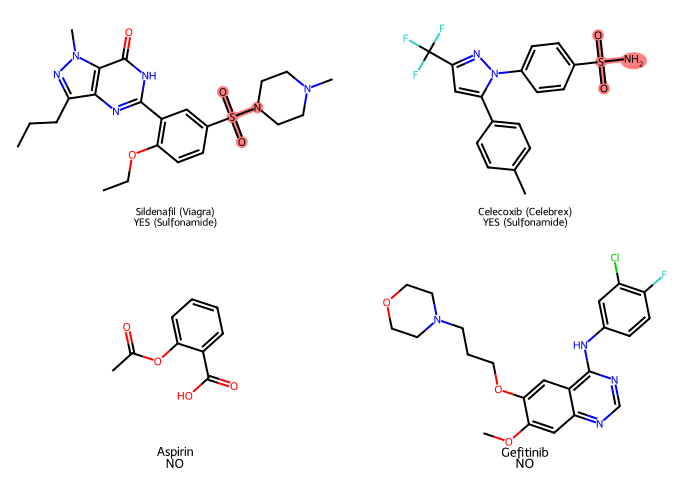

In [6]:
challenge_mols = {
    "Sildenafil (Viagra)": "CCCC1=NN(C)C2=C1N=C(NC2=O)C3=C(OCC)C=CC(=C3)S(=O)(=O)N4CCN(C)CC4",
    "Celecoxib (Celebrex)": "CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F",
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Gefitinib": "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4"
}

sulfonamide_smarts = Chem.MolFromSmarts("S(=O)(=O)[NX3]")

mols_list = []
matched_atoms_list = []
legends_list = []

for name, smi in challenge_mols.items():
    m = Chem.MolFromSmiles(smi)
    match = m.GetSubstructMatch(sulfonamide_smarts)
    has_grp = len(match) > 0
    
    mols_list.append(m)
    matched_atoms_list.append(match if has_grp else [])
    status = "YES (Sulfonamide)" if has_grp else "NO"
    legends_list.append(f"{name}\n{status}")

Draw.MolsToGridImage(
    mols_list,
    legends=legends_list,
    highlightAtomLists=matched_atoms_list,
    molsPerRow=2,
    subImgSize=(350, 240)
)

## 6. Summary & Key Takeaways
* **SMARTS** is the regex of chemistry: it lets you search for substructural patterns, generic atom types, and ring topologies.
* `mol.HasSubstructMatch(query)` returns a fast boolean check; `mol.GetSubstructMatches(query)` returns the matched atom indices.
* Combining SMARTS queries allows building automated functional group classifiers and medicinal chemistry filter catalogs.

**Next Up in Video 10:** **Molecular Standardization & Dataset Curation Pipeline** — salt stripping, charge neutralization, tautomer canonicalization, and deduplication!